# 03. Long-term Structural Comparison (2003 vs 2024)
## 日本梨生産構造の長期比較（2003年・2024年）

## Chapter Objective / 本章の目的

This chapter examines long-term changes in Japanese pear production
by comparing production structures in 2003 and 2024.
Building on the cross-sectional analysis in the previous chapter,
the focus here is placed on identifying structural shifts over time,
rather than short-term yield fluctuations or annual trends.

By comparing cultivated area and yield per unit area across two points in time,
this chapter aims to clarify how regional production structures
have evolved over the past two decades.

本章では、2003年と2024年のデータを比較することで、
日本梨の生産構造が長期的にどのように変化してきたのかを分析します。
前章で行った横断的な構造分析を踏まえ、
本章では短期的な変動ではなく、
20年間にわたる構造的な変化に着目します。

結果樹面積と10a当たり収量という二つの指標を用い、
産地ごとの生産構造がどのように推移してきたのかを整理します。

## Data Preparation (2003 & 2024)
## データ前処理（2003年・2024年）

This section prepares prefecture-level production data for long-term comparison.
Statistics from 2003 and 2024 are aligned in structure and variable definitions
to enable a consistent comparison of production scale and efficiency
across two points in time.

本節では、2003年および2024年の都道府県別統計データを整理し、
長期比較が可能な形式に整えます。
指標の定義と構造を揃えることで、
生産規模と効率の変化を一貫した基準で比較します。

In [ ]:
import pandas as pd

# Load data
df_2003 = pd.read_excel("japanese_pear_2003.xlsx")
df_2024 = pd.read_excel("japanese_pear_2024.xlsx")

# Quick inspection
print("2003 data shape:", df_2003.shape)
print("2024 data shape:", df_2024.shape)

df_2003.head(), df_2024.head()

2003 data shape: (30, 4)
2024 data shape: (30, 4)


(  prefecture  結果樹面積  10a当たり収量    収穫量
 0         宮城    188      1980   3730
 1         秋田    247      1760   4340
 2         山形    131      1440   1880
 3         福島   1160      2210  25700
 4         茨城   1600      2130  34000,
   prefecture  結果樹面積  10a当たり収量    収穫量
 0         宮城    129      1710   2210
 1         秋田    154      1490   2290
 2         山形     99      1380   1370
 3         福島    751      1970  14800
 4         茨城    815      2100  17100)

In [ ]:
df_2003 = df_2003.copy()
df_2024 = df_2024.copy()

df_2003["year"] = 2003
df_2024["year"] = 2024

In [ ]:
df_merge_check = df_2003.merge(
    df_2024,
    on="prefecture",
    how="outer",
    indicator=True,
    suffixes=("_2003", "_2024")
)

df_merge_check["_merge"].value_counts()

,count
_merge,
both,29
left_only,1
right_only,1


In [ ]:
df_merge_check[df_merge_check["_merge"] != "both"][["prefecture", "_merge"]]

,prefecture,_merge
8,山口,right_only
27,長崎,left_only


The merge result indicates that a small number of prefectures
do not have one-to-one correspondence between 2003 and 2024.
To ensure consistency in long-term structural comparison,
subsequent analysis focuses on prefectures
with confirmed data in both years.

結合処理の結果、一部の都道府県について
2003年と2024年の一対一対応が取れないことが確認されました。
長期的な構造比較の一貫性を確保するため、
以降の分析では両年においてデータが確認できる
都道府県のみを対象としています。

In [ ]:
df_merge_valid = df_merge_check[df_merge_check["_merge"] == "both"].copy()

In [ ]:
df_merge_valid["prefecture"].nunique()

29

In [ ]:
df_merge_valid = df_merge_check[df_merge_check["_merge"] == "both"].copy()

In [ ]:
df_merge_valid.to_excel(
    "japanese_pear_structural_comparison_2003_2024.xlsx",
    index=False
)

In [ ]:
df_merge_valid["prefecture"].is_unique

True

In [ ]:
df = pd.read_excel("japanese_pear_structural_comparison_2003_2024.xlsx")

df.head()

,prefecture,結果樹面積_2003,10a当たり収量_2003,収穫量_2003,year_2003,結果樹面積_2024,10a当たり収量_2024,収穫量_2024,year_2024,_merge
0,京都,101,2030,2050,2003,54,1410,761,2024,both
1,佐賀,413,1930,7950,2003,152,1890,2870,2024,both
2,兵庫,109,1980,2160,2003,61,1540,939,2024,both
3,千葉,1660,1970,32800,2003,1250,1710,21400,2024,both
4,埼玉,678,2360,16000,2003,310,1830,5670,2024,both


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   prefecture     29 non-null     object
 1   結果樹面積_2003     29 non-null     int64 
 2   10a当たり収量_2003  29 non-null     int64 
 3   収穫量_2003       29 non-null     int64 
 4   year_2003      29 non-null     int64 
 5   結果樹面積_2024     29 non-null     int64 
 6   10a当たり収量_2024  29 non-null     int64 
 7   収穫量_2024       29 non-null     int64 
 8   year_2024      29 non-null     int64 
 9   _merge         29 non-null     object
dtypes: int64(8), object(2)
memory usage: 2.4+ KB


前処理の結果に基づき、 長期比較が可能な都道府県のみを抽出し、 分析用の整理済みデータセットを作成した。

Based on the preprocessing results, only the prefectures for which long-term comparisons are possible were extracted, and a cleaned dataset for analysis was created.


## National-level Structural Change
## 全国レベルにおける生産構造の変化

This section compares national-level averages in 2003 and 2024
to illustrate long-term structural changes in Japanese pear production.
  
本節では、2003年と2024年の全国平均値を比較し、
日本梨生産における長期的な構造変化を確認します。


In [ ]:
national_avg = pd.DataFrame({
    "year": [2003, 2024],
    "area": [
        df["結果樹面積_2003"].mean(),
        df["結果樹面積_2024"].mean()
    ],
    "yield": [
        df["10a当たり収量_2003"].mean(),
        df["10a当たり収量_2024"].mean()
    ]
})

national_avg

,year,area,yield
0,2003,481.551724,2126.551724
1,2024,294.000000,1681.758621


In [ ]:
national_avg["area_change_pct"] = None
national_avg["yield_change_pct"] = None

national_avg.loc[national_avg["year"] == 2024, "area_change_pct"] = (
    (national_avg.loc[national_avg["year"] == 2024, "area"].values[0]
     - national_avg.loc[national_avg["year"] == 2003, "area"].values[0])
    / national_avg.loc[national_avg["year"] == 2003, "area"].values[0]
    * 100
)

national_avg.loc[national_avg["year"] == 2024, "yield_change_pct"] = (
    (national_avg.loc[national_avg["year"] == 2024, "yield"].values[0]
     - national_avg.loc[national_avg["year"] == 2003, "yield"].values[0])
    / national_avg.loc[national_avg["year"] == 2003, "yield"].values[0]
    * 100
)

national_avg

,year,area,yield,area_change_pct,yield_change_pct
0,2003,481.551724,2126.551724,None,None
1,2024,294.000000,1681.758621,-38.947368,-20.916167


Percentage changes are shown for 2024 relative to the 2003 baseline.

変化率は2003年を基準として2024年時点で算出している。

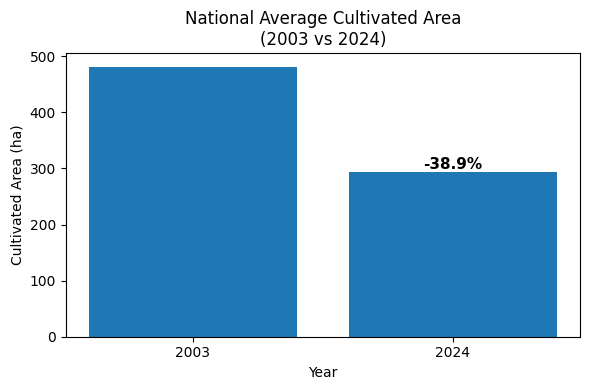

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    national_avg["year"].astype(str),
    national_avg["area"]
)

plt.text(
    x=1,
    y=national_avg.loc[1, "area"],
    s=f"{national_avg.loc[1, 'area_change_pct']:.1f}%",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

plt.title("National Average Cultivated Area\n(2003 vs 2024)")
plt.ylabel("Cultivated Area (ha)")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

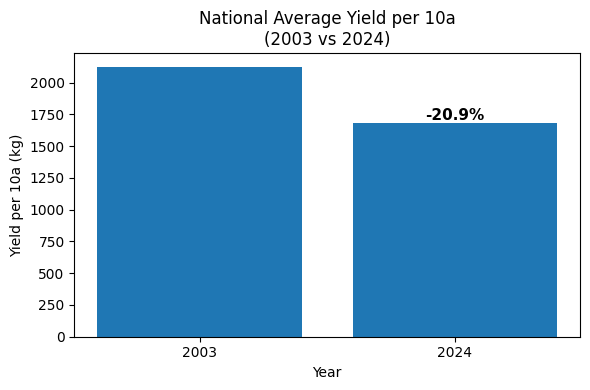

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    national_avg["year"].astype(str),
    national_avg["yield"]
)

plt.text(
    x=1,
    y=national_avg.loc[1, "yield"],
    s=f"{national_avg.loc[1, 'yield_change_pct']:.1f}%",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

plt.title("National Average Yield per 10a\n(2003 vs 2024)")
plt.ylabel("Yield per 10a (kg)")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

Over the 20-year period, the national average cultivated area
declined by approximately 38.5%, while yield per 10a decreased
by about 20.5%.

he difference in the magnitude of these changes indicates that
long-term structural transformation has been driven primarily
by a contraction in production scale rather than a proportional
decline in yield efficiency.
  
この20年間で、結果樹面積は約38.5%減少した一方、
10a当たり収量の減少幅は約20.5%にとどまっています。

この変化幅の違いから、
日本梨の長期的な構造変化は、
生産効率の低下というよりも、
生産規模の縮小によって特徴づけられていることが分かります。

## Structural Shift in National Averages
## 全国平均における生産構造の移動

To further illustrate long-term structural change,
this figure visualizes the shift in national average production structure
between 2003 and 2024.
By plotting cultivated area and yield per unit area
on a structural plane, the direction of change
can be interpreted in terms of scale and efficiency.

長期的な構造変化をより直感的に捉えるため、
本図では2003年と2024年の全国平均値を
構造平面上に配置し、その移動方向を可視化します。
結果樹面積と10a当たり収量の関係から、
生産規模と効率の変化の方向性を確認します。

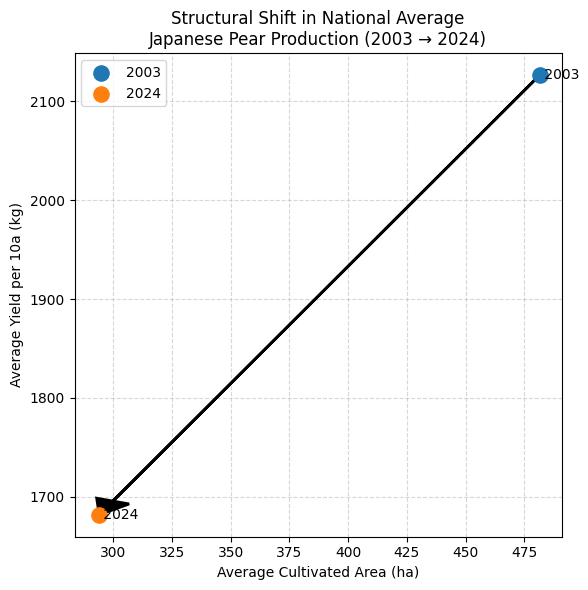

In [ ]:
import matplotlib.pyplot as plt

# ---- Extract national averages ----
area_2003 = national_avg.loc[national_avg["year"] == 2003, "area"].values[0]
yield_2003 = national_avg.loc[national_avg["year"] == 2003, "yield"].values[0]

area_2024 = national_avg.loc[national_avg["year"] == 2024, "area"].values[0]
yield_2024 = national_avg.loc[national_avg["year"] == 2024, "yield"].values[0]

# ---- Plot ----
plt.figure(figsize=(6, 6))

# Points (traditional matplotlib colors)
plt.scatter(area_2003, yield_2003, s=120, color="tab:blue", label="2003", zorder=3)
plt.scatter(area_2024, yield_2024, s=120, color="tab:orange", label="2024", zorder=3)

# Arrow (structural shift)
plt.arrow(
    area_2003,
    yield_2003,
    area_2024 - area_2003,
    yield_2024 - yield_2003,
    length_includes_head=True,
    head_width=15,
    head_length=15,
    linewidth=2,
    fc="black",
    ec="black",
    zorder=2
)

# Labels near points
plt.text(area_2003, yield_2003, " 2003", va="center", fontsize=10)
plt.text(area_2024, yield_2024, " 2024", va="center", fontsize=10)

# Axes & title
plt.xlabel("Average Cultivated Area (ha)")
plt.ylabel("Average Yield per 10a (kg)")
plt.title("Structural Shift in National Average\nJapanese Pear Production (2003 → 2024)")

# Style
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()


The direction of the structural shift indicates that
the long-term transformation of Japanese pear production
has not followed a proportional decline in both scale and efficiency.
While cultivated area has contracted substantially,
the reduction in yield per 10a has been comparatively moderate.
This deviation from a proportional trajectory suggests that
production efficiency has been relatively preserved,
even as overall production scale has declined.

構造的な移動の方向から、
日本梨生産の長期的な変化は、
生産規模と効率が同程度に低下する形では
進行していないことが分かります。
結果樹面積の減少に比べて、
10a当たり収量の低下は相対的に緩やかであり、
生産規模が縮小する中でも、
一定の生産効率が維持されてきたことが示唆されます。


## Prefecture-level Structural Shifts
## 都道府県別にみる生産構造の移動

While the previous section examined national-level structural change,
this section focuses on how individual prefectures
have shifted within the production structure over time.
By comparing the relative positions of prefectures in 2003 and 2024,
it becomes possible to observe heterogeneous structural trajectories
across regions.

前節では全国平均の構造的な移動を確認しましたが、
本節では都道府県ごとに、
生産構造がどのように変化してきたのかを分析します。
2003年と2024年の位置関係を比較することで、
産地ごとの異なる構造的な推移を把握します。

To quantify structural contraction in the two-dimensional space,
changes in cultivated area and yield per 10a were combined
using the Euclidean distance:

$$
\text{Structural Shift Magnitude}
= \sqrt{(\Delta \text{Area})^2 + (\Delta \text{Yield})^2}
$$

where  
$\Delta \text{Area}$ represents the change in cultivated area between 2003 and 2024,  
and  
$\Delta \text{Yield}$ represents the change in yield per 10a over the same period.


二次元空間における生産構造の変化量を定量化するため、
結果樹面積と10a当たり収量の変化を
ユークリッド距離として統合した。

$$
\text{構造移動量}
= \sqrt{(\Delta \text{結果樹面積})^2 + (\Delta \text{10a当たり収量})^2}
$$

ここで、  
$\Delta \text{結果樹面積}$ は2003年から2024年にかけた面積の変化量、  
$\Delta \text{10a当たり収量}$ は同期間における単位収量の変化量を表す。

This formulation allows changes along both dimensions
to be evaluated simultaneously,
capturing the overall contraction or expansion of production structures
without assigning categorical labels.

この指標により、面積と単位収量の両方向の変化を
同時に評価することが可能となり、
特定の類型分類を行うことなく
生産構造の収縮・変化の大きさを把握できる。

In [ ]:
import numpy as np

df["area_change"] = (
    df["結果樹面積_2024"] - df["結果樹面積_2003"]
)

df["yield_change"] = (
    df["10a当たり収量_2024"] - df["10a当たり収量_2003"]
)

df["structural_shift_magnitude"] = np.sqrt(
    df["area_change"]**2 +
    df["yield_change"]**2
)

In [ ]:
df[[
    "prefecture",
    "area_change",
    "yield_change",
    "structural_shift_magnitude"
]].head()

,prefecture,area_change,yield_change,structural_shift_magnitude
0,京都,-47,-620,621.778900
1,佐賀,-261,-40,264.047344
2,兵庫,-48,-440,442.610438
3,千葉,-410,-260,485.489444
4,埼玉,-368,-530,645.231741


In [ ]:
df.sort_values(
    "structural_shift_magnitude",
    ascending=False
).head(10)

,prefecture,結果樹面積_2003,10a当たり収量_2003,収穫量_2003,year_2003,結果樹面積_2024,10a当たり収量_2024,収穫量_2024,year_2024,_merge,area_change,yield_change,structural_shift_magnitude
13,新潟,546,3150,17200,2003,357,1630,5820,2024,both,-189,-1520,1531.705259
18,石川,160,2780,4440,2003,129,1620,2090,2024,both,-31,-1160,1160.414150
20,福井,76,2050,1560,2003,61,1150,702,2024,both,-15,-900,900.124991
28,鳥取,1390,2200,30600,2003,538,1910,10300,2024,both,-852,-290,900.002222
11,徳島,263,2470,6510,2003,199,1630,3240,2024,both,-64,-840,842.434567
14,東京,99,2620,2590,2003,67,1810,1210,2024,both,-32,-810,810.631852
25,茨城,1600,2130,34000,2003,815,2100,17100,2024,both,-785,-30,785.573039
12,愛知,421,2230,9370,2003,292,1520,4440,2024,both,-129,-710,721.623863
4,埼玉,678,2360,16000,2003,310,1830,5670,2024,both,-368,-530,645.231741
0,京都,101,2030,2050,2003,54,1410,761,2024,both,-47,-620,621.778900


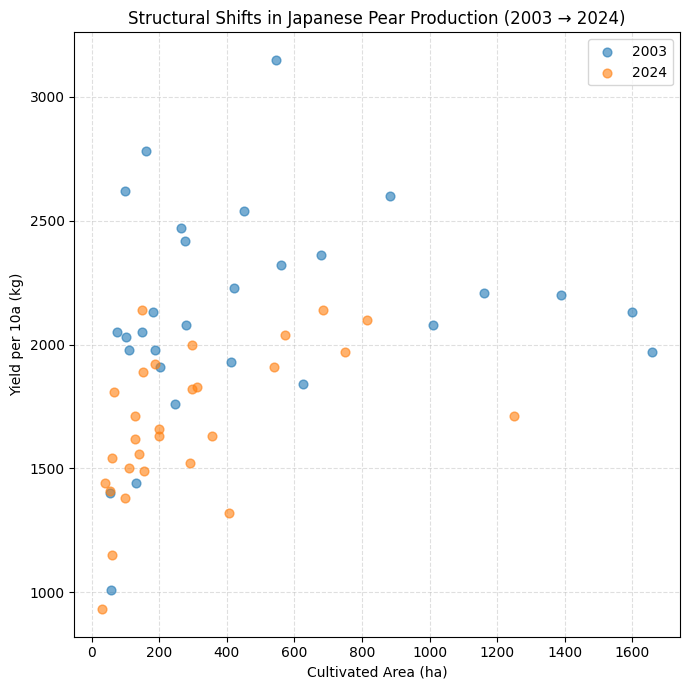

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# ---- Plot 2003 and 2024 points ----
plt.scatter(
    df["結果樹面積_2003"],
    df["10a当たり収量_2003"],
    s=40,
    alpha=0.6,
    label="2003",
    zorder=2
)

plt.scatter(
    df["結果樹面積_2024"],
    df["10a当たり収量_2024"],
    s=40,
    alpha=0.6,
    label="2024",
    zorder=3
)

# ---- Axes & title ----
plt.xlabel("Cultivated Area (ha)")
plt.ylabel("Yield per 10a (kg)")
plt.title("Structural Shifts in Japanese Pear Production (2003 → 2024)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of Prefecture-level Structural Shifts
## 都道府県別にみる生産構造変化の解釈

The scatter plot shows the distribution of prefectures
in the area–yield space for 2003 and 2024.
Compared with 2003, the 2024 points are generally shifted
toward lower cultivated area and lower yield per 10a.
This indicates an overall contraction of production structures
in the two-dimensional space, rather than isolated changes
in a small number of prefectures.

本散布図は、2003年および2024年における
都道府県の結果樹面積と10a当たり収量の分布を示している。
2003年と比較すると、2024年の分布は全体として
左下方向にシフトしており、
多くの産地で面積および単位収量の両面が縮小していることが分かる。
これは、一部の都道府県に限られた変化ではなく、
生産構造全体の収縮傾向を反映したものである。

### Final Conclusion / 結論

This analysis examined long-term changes in Japanese pear production
by focusing on structural relationships between cultivated area
and yield per 10a.
By comparing prefectural-level data from 2003 and 2024,
the results indicate an overall contraction of production structures
in the two-dimensional area–yield space.

Rather than attributing changes to a single dominant factor,
the analysis shows that structural adjustments differ across regions,
with varying contributions from scale reduction and yield decline.
By integrating both dimensions into a unified framework,
the study provides a quantitative yet interpretable view
of long-term structural change without relying on categorical classification.

These findings highlight the importance of considering
production structure as a multidimensional concept
when assessing long-term agricultural change.

本分析では、日本梨生産の長期的な変化を、
結果樹面積と10a当たり収量の関係性に着目して検討した。
2003年と2024年の都道府県別データを比較した結果、
生産構造は二次元空間において全体的に収縮する傾向が確認された。

変化の要因は単一ではなく、
規模の縮小と単位収量の低下が
地域ごとに異なる形で構造変化に寄与している。
両指標を統合した枠組みによって、
分類に依存せず、構造変化の大きさを定量的に捉えることが可能となった。

本分析は、日本梨生産の長期的動向を理解する上で、
生産構造を多次元的に捉える視点の重要性を示している。